In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset

df = pd.read_csv("housing - housing.csv")

In [3]:
# Display First Five Records

print(df.head())

# Display Numerical Columns

print(df.select_dtypes(include="number").columns)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
      

In [4]:
# Calculate Correlation Matrix

correlation = df.corr(numeric_only=True)
print(correlation)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071035      -0.079809   
housing_

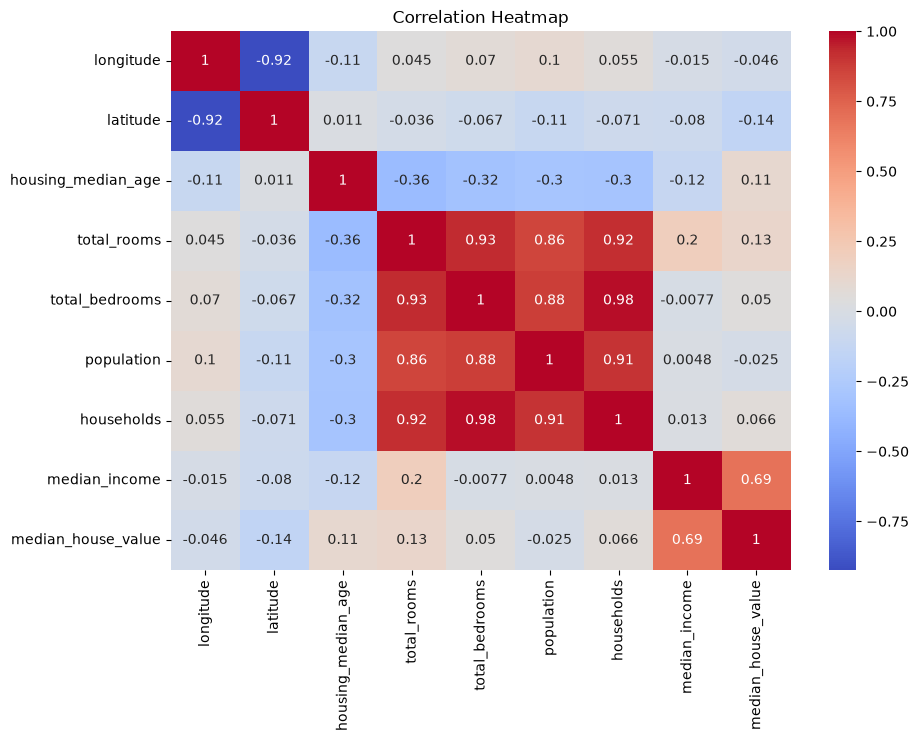

In [5]:
# Display Correlation Heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

PRACTICAL 3B

In [6]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
# Load Dataset

df = pd.read_csv("housing - housing.csv")

In [8]:
# Select Independent and Dependent Variables

X = df[["median_income"]]
y = df["median_house_value"]

In [9]:
# Split Dataset into Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [10]:
# Create Linear Regression Model

model = LinearRegression()

In [11]:
# Train the Model

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[41933.85]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['median_income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.446e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [12]:
# Display Coefficient and Intercept

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 41933.84939381274
Intercept: 44459.729169078666


In [13]:
# Predict House Values

y_pred = model.predict(X_test)

In [14]:
# Display First 10 Predictions

print("Predicted Values:")

print(y_pred[:10])

Predicted Values:
[114958.91676996 150606.88213964 190393.71844449 285059.38345102
 200663.31816103 242165.24890609 257647.22610228 199229.18051176
 245893.1681172  384677.43607096]


In [15]:
# Calculate Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 7091157771.76555


In [16]:
# Calculate R2 Score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.45885918903846656


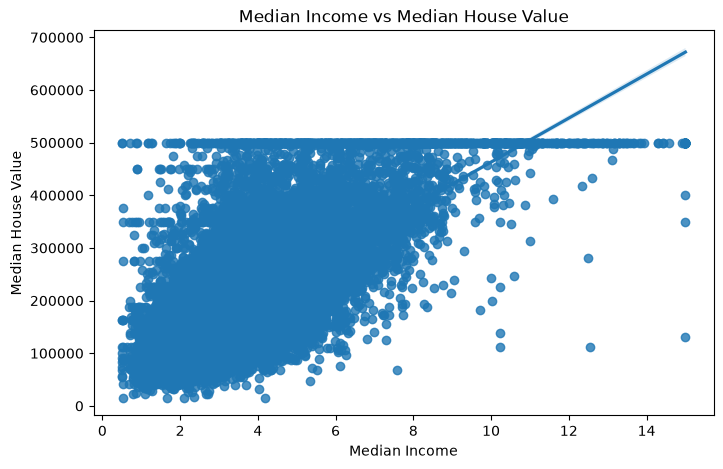

In [17]:
# Scatter Plot with Regression Line

plt.figure(figsize=(8, 5))

sns.regplot(
    x="median_income",
    y="median_house_value",
    data=df
)

plt.xlabel("Median Income")

plt.ylabel("Median House Value")

plt.title("Median Income vs Median House Value")

plt.show()

EXTRA IN PDF

Complete Correlation Matrix:
                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.0710

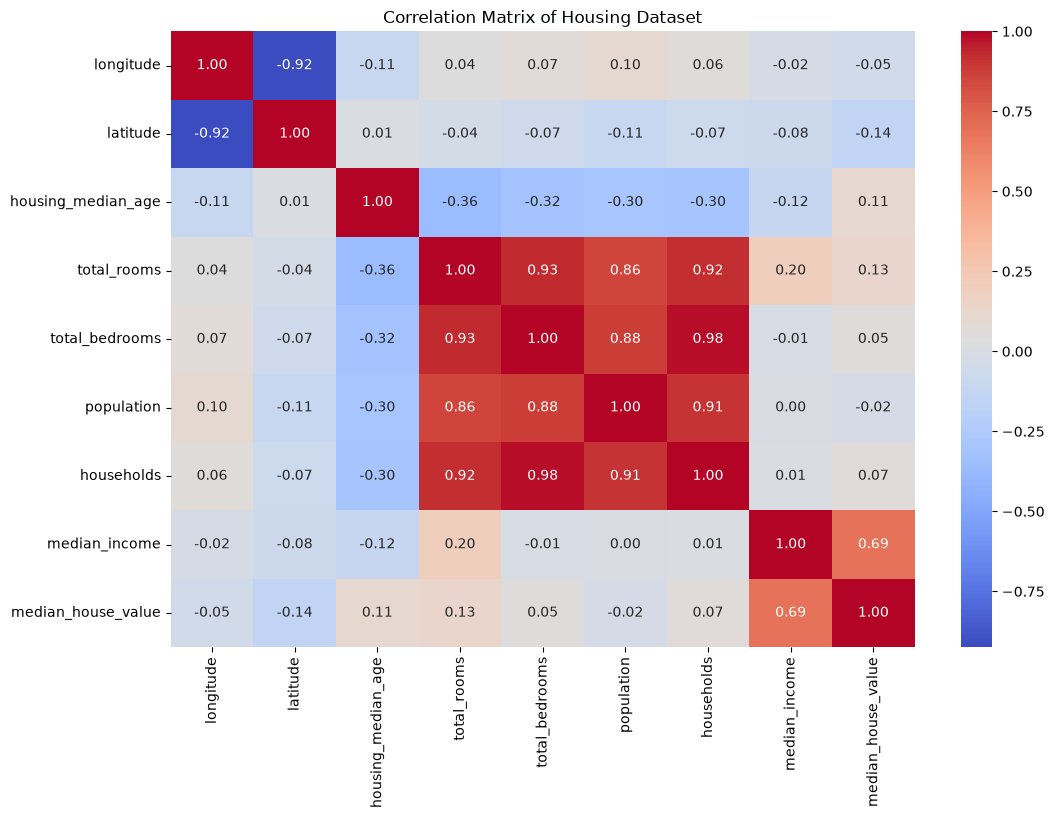

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("housing - housing.csv")

# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

print("Complete Correlation Matrix:")
print(correlation_matrix)

# Find unique pairs of variables
pairs = []

columns = correlation_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        pairs.append(
            (
                columns[i],
                columns[j],
                correlation_matrix.iloc[i, j]
            )
        )

# Strongest positive correlation
strongest_positive = max(pairs, key=lambda x: x[2])

# Strongest negative correlation
strongest_negative = min(pairs, key=lambda x: x[2])

# Weakest correlation - closest to zero
weakest = min(pairs, key=lambda x: abs(x[2]))

print("\nStrongest Positive Correlation:")
print(strongest_positive)

print("\nStrongest Negative Correlation:")
print(strongest_negative)

print("\nWeakest Correlation:")
print(weakest)

# Display heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Housing Dataset")

plt.show()

In [46]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


# Load dataset
df = pd.read_csv("housing - housing.csv")


# Select required columns
features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "population",
    "households"
]

target = "median_house_value"


# Remove missing values
data = df[features + [target]].dropna()


# -------------------------------
# Multiple Linear Regression
# -------------------------------

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

y_pred = multiple_model.predict(X_test)

r2_multiple = r2_score(y_test, y_pred)
mse_multiple = mean_squared_error(y_test, y_pred)


print("MULTIPLE LINEAR REGRESSION")
print("--------------------------------")
print("R2 Score:", r2_multiple)
print("Mean Squared Error:", mse_multiple)


# -------------------------------
# Simple Linear Regression
# median_income -> median_house_value
# -------------------------------

X_simple = data[["median_income"]]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train_s, y_train_s)

y_pred_s = simple_model.predict(X_test_s)

r2_simple = r2_score(y_test_s, y_pred_s)
mse_simple = mean_squared_error(y_test_s, y_pred_s)


print("\nSIMPLE LINEAR REGRESSION")
print("--------------------------------")
print("R2 Score:", r2_simple)
print("Mean Squared Error:", mse_simple)


# -------------------------------
# Comparison
# -------------------------------

print("\nMODEL COMPARISON")
print("--------------------------------")

print("Multiple Regression R2:", r2_multiple)
print("Simple Regression R2:", r2_simple)

print("Multiple Regression MSE:", mse_multiple)
print("Simple Regression MSE:", mse_simple)

MULTIPLE LINEAR REGRESSION
--------------------------------
R2 Score: 0.5490012551168503
Mean Squared Error: 5909928044.702565

SIMPLE LINEAR REGRESSION
--------------------------------
R2 Score: 0.45885918903846656
Mean Squared Error: 7091157771.76555

MODEL COMPARISON
--------------------------------
Multiple Regression R2: 0.5490012551168503
Simple Regression R2: 0.45885918903846656
Multiple Regression MSE: 5909928044.702565
Simple Regression MSE: 7091157771.76555


In [47]:
import pandas as pd

# Load dataset
df = pd.read_csv("housing - housing.csv")

# Calculate correlation
correlation = df["total_rooms"].corr(
    df["median_house_value"]
)

print("Correlation between total_rooms and median_house_value:")
print(correlation)

Correlation between total_rooms and median_house_value:
0.1341531138065631
